# Exploration du projet `TEXT-RECOGNITION-USING-PYTHON`

Repository: [rohit518/TEXT-RECOGNITION-USING-PYTHON](https://github.com/rohit518/TEXT-RECOGNITION-USING-PYTHON)

## Objectifs
- Cloner le dépôt localement
- Inspecter la structure du projet
- Lire les fichiers clés (`README.md`, `runner.py`)
- Identifier les dépendances OCR et le pipeline d'exécution

In [43]:
from pathlib import Path
import subprocess
import json
import re

REPO_URL = "https://github.com/rohit518/TEXT-RECOGNITION-USING-PYTHON.git"
TARGET_DIR = Path("C:/Users/mvm/open3d_vision/external/TEXT-RECOGNITION-USING-PYTHON")
TARGET_DIR.parent.mkdir(parents=True, exist_ok=True)

if not TARGET_DIR.exists():
    print(f"Clonage vers: {TARGET_DIR}")
    subprocess.run(["git", "clone", REPO_URL, str(TARGET_DIR)], check=True)
else:
    print(f"Dépôt déjà présent: {TARGET_DIR}")
    subprocess.run(["git", "-C", str(TARGET_DIR), "pull", "--ff-only"], check=False)

print("Prêt.")

Dépôt déjà présent: C:\Users\mvm\open3d_vision\external\TEXT-RECOGNITION-USING-PYTHON
Prêt.


In [44]:
# Arborescence rapide
# Adapté pour accepter une arborescence absolue ou relative

from pathlib import PurePath

# Pour obtenir la liste de tous les fichiers récursivement, on utilise '**/*'
project_files = sorted([p for p in TARGET_DIR.rglob('*') if p.is_file()])

print(f"Nombre de fichiers: {len(project_files)}")
for p in project_files[:60]:
    # Affichage du chemin absolu ou relatif selon le besoin
    try:
        rel = p.relative_to(TARGET_DIR)
        print("-", rel)
    except ValueError:
        # Si le chemin n'est pas relatif à TARGET_DIR, affiche le chemin absolu
        print("-", p)
if len(project_files) > 60:
    print(f"... ({len(project_files)-60} fichiers supplémentaires)")

Nombre de fichiers: 42
- .git\config
- .git\description
- .git\FETCH_HEAD
- .git\HEAD
- .git\hooks\applypatch-msg.sample
- .git\hooks\commit-msg.sample
- .git\hooks\fsmonitor-watchman.sample
- .git\hooks\post-update.sample
- .git\hooks\pre-applypatch.sample
- .git\hooks\pre-commit.sample
- .git\hooks\pre-merge-commit.sample
- .git\hooks\pre-push.sample
- .git\hooks\pre-rebase.sample
- .git\hooks\pre-receive.sample
- .git\hooks\prepare-commit-msg.sample
- .git\hooks\push-to-checkout.sample
- .git\hooks\sendemail-validate.sample
- .git\hooks\update.sample
- .git\index
- .git\info\exclude
- .git\logs\HEAD
- .git\logs\refs\heads\main
- .git\logs\refs\remotes\origin\HEAD
- .git\objects\pack\pack-81985ecac83c337ede57f7534cacea5ca678046b.idx
- .git\objects\pack\pack-81985ecac83c337ede57f7534cacea5ca678046b.pack
- .git\objects\pack\pack-81985ecac83c337ede57f7534cacea5ca678046b.rev
- .git\ORIG_HEAD
- .git\packed-refs
- .git\refs\heads\main
- .git\refs\remotes\origin\HEAD
- 1.jpg
- 1234.png
- a.

In [45]:
# Lecture README
readme_path = TARGET_DIR / "README.md"
if readme_path.exists():
    readme_text = readme_path.read_text(encoding="utf-8", errors="ignore")
    print(readme_text[:4000])
else:
    print("README.md introuvable")


# TEXT-RECOGNITION-USING-PYTHON



Text Recognition from images is an active research 
area which attempts to develop a computer application 
with the ability to automatically read texts from images.
The project is based on the same idea. Scene based text detection,
document scanning, 2d image scanning are the main highlights.

Language used-PYTHON 

Modules Used-Opencv,Pytesseract,Easyocr,Tkinter


## Dependencies
Python-tesseract is a wrapper for Google’s Tesseract-OCR Engine(https://github.com/tesseract-ocr/tesseract).
It can read all image types supported by the Pillow and Leptonica 
imaging libraries, 
including jpeg, png, gif, bmp, tiff, and others. In addition it can also 
extract text from images and write it into another file.
```bash
pip install pytesseract
```
Specify the tesseract.exe directory in the code to the cmd.

Here it is in my case-
p.pytesseract.tesseract_cmd=r'C:\Users\hp\AppData\Local\Tesseract-OCR\tesseract.exe'

For Windows, please install torch and torchvisi

In [46]:
# Lecture du script principal
runner_path = TARGET_DIR / "runner.py"
if runner_path.exists():
    runner_text = runner_path.read_text(encoding="utf-8", errors="ignore")
    print("Taille runner.py:", len(runner_text), "caractères")
    print("\n--- Extrait début ---\n")
    print(runner_text[:3000])
else:
    print("runner.py introuvable")

Taille runner.py: 7160 caractères

--- Extrait début ---

import sys
import matplotlib as plt
from tkinter import *
from tkinter import ttk
import tkinter.filedialog
from tkinter.filedialog import askopenfilename
from PIL import Image,ImageTk
import cv2
import numpy as np
import easyocr
import imutils
from imutils.contours import sort_contours
import time
import pytesseract as p
p.pytesseract.tesseract_cmd=r'C:\Users\hp\AppData\Local\Tesseract-OCR\tesseract.exe'
def resize(pic):
    chng=cv2.resize(pic,(900,600))
    return chng
def max_bound_area(items):
    big=np.array([])
    max_area=0
    for i in items:
        area=cv2.contourArea(i)
        if area>5000:
            perimeter=cv2.arcLength(i,True)
            approx=cv2.approxPolyDP(i,0.02*perimeter,True)
            if (area>max_area) and len(approx)==4:
                big=approx
                max_area=area
    return big,max_area
def sort_contour_points(points):
    points=points.reshape((4,2))
    b=np.zeros((4,1,2),dtyp

In [47]:
# Analyse des imports pour identifier les dépendances
imports = []
for line in runner_text.splitlines():
    s = line.strip()
    if s.startswith("import ") or s.startswith("from "):
        imports.append(s)

print("Imports détectés dans runner.py:")
for imp in sorted(set(imports)):
    print("-", imp)

keywords = ["pytesseract", "easyocr", "cv2", "tkinter", "PIL", "torch"]
print("\nPrésence de mots-clés:")
lower_runner = runner_text.lower()
for k in keywords:
    print(f"- {k}:", k.lower() in lower_runner)

Imports détectés dans runner.py:
- from PIL import Image,ImageTk
- from imutils.contours import sort_contours
- from tkinter import *
- from tkinter import ttk
- from tkinter.filedialog import askopenfilename
- import cv2
- import easyocr
- import imutils
- import matplotlib as plt
- import numpy as np
- import pytesseract as p
- import sys
- import time
- import tkinter.filedialog

Présence de mots-clés:
- pytesseract: True
- easyocr: True
- cv2: True
- tkinter: True
- PIL: True
- torch: False


## Résumé d'exploration

D'après le README, le projet cible trois modes:
- Scene detection (plaques, panneaux, etc.)
- Document scanner
- 2D image scanner (images inclinées/skewed)

Stack annoncée:
- `opencv`
- `pytesseract`
- `easyocr`
- `tkinter`
- `Pillow`

Source de référence:
- [README du dépôt](https://github.com/rohit518/TEXT-RECOGNITION-USING-PYTHON)

In [48]:
# (Optionnel) Préparer un mini plan de test local
test_plan = {
    "1_install": [
        "pip install opencv-python pytesseract easyocr pillow"
    ],
    "2_tesseract_windows": [
        "Installer Tesseract OCR",
        "Configurer pytesseract.pytesseract.tesseract_cmd"
    ],
    "3_run": [
        "python runner.py",
        "Tester les 3 modes via l'UI tkinter"
    ]
}
print(json.dumps(test_plan, indent=2, ensure_ascii=False))

{
  "1_install": [
    "pip install opencv-python pytesseract easyocr pillow"
  ],
  "2_tesseract_windows": [
    "Installer Tesseract OCR",
    "Configurer pytesseract.pytesseract.tesseract_cmd"
  ],
  "3_run": [
    "python runner.py",
    "Tester les 3 modes via l'UI tkinter"
  ]
}


## Inférence OCR locale sur une image cible

Image à traiter : `C:\Users\mvm\open3d_vision\data\image_texte.jpg`

Cette section ajoute un pipeline d'inférence direct (hors UI Tkinter) pour obtenir rapidement le texte détecté.

Image: C:\Users\mvm\open3d_vision\data\image_texte.jpg
Shape: 1843x1382 px


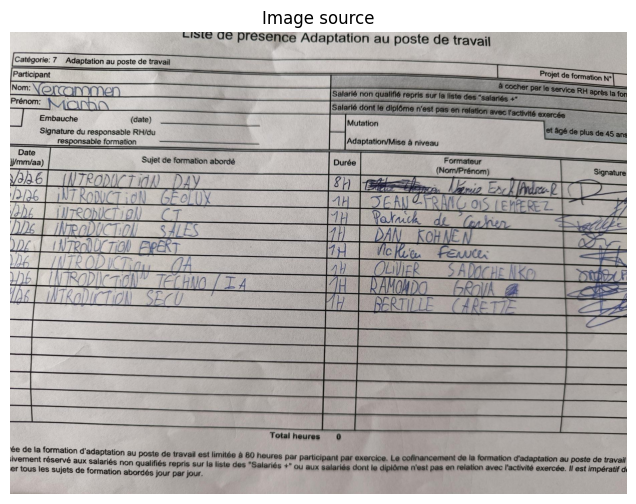

In [49]:
# Configuration image + affichage
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = Path(r"C:\Users\mvm\open3d_vision\data\image_texte.jpg")
if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Image introuvable: {IMAGE_PATH}")

img_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise ValueError("Impossible de lire l'image avec OpenCV.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"Image: {IMAGE_PATH}")
print(f"Shape: {img_rgb.shape[1]}x{img_rgb.shape[0]} px")

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title("Image source")
plt.axis("off")
plt.show()

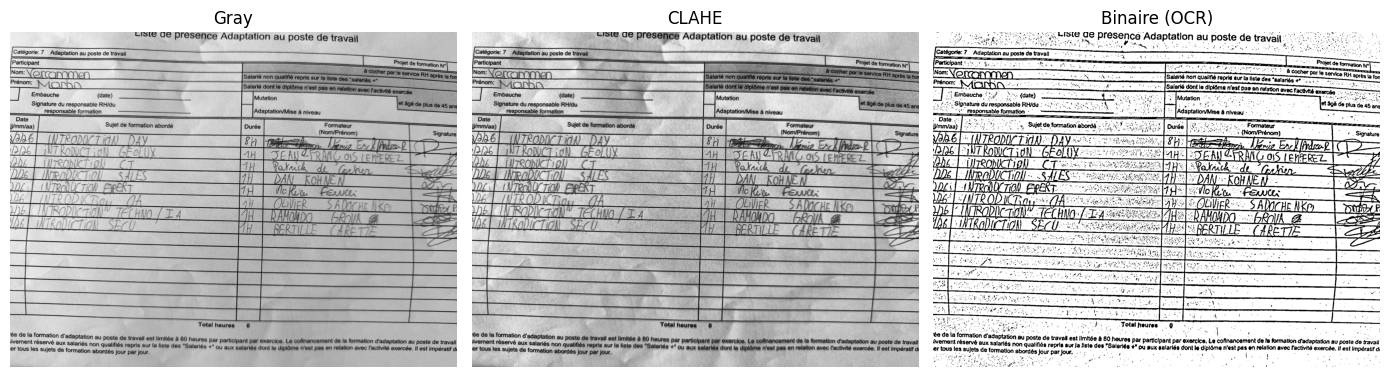

In [50]:
# Prétraitements utiles pour OCR
# On prépare plusieurs versions, puis on choisit la plus adaptée selon le moteur OCR.

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Amélioration contraste local
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(gray)

# Binarisation adaptative
bin_adapt = cv2.adaptiveThreshold(
    gray_clahe, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10
)

# Débruitage léger
bin_denoised = cv2.medianBlur(bin_adapt, 3)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Gray'); ax[0].axis('off')
ax[1].imshow(gray_clahe, cmap='gray'); ax[1].set_title('CLAHE'); ax[1].axis('off')
ax[2].imshow(bin_denoised, cmap='gray'); ax[2].set_title('Binaire (OCR)'); ax[2].axis('off')
plt.tight_layout()
plt.show()

Using CPU. Note: This module is much faster with a GPU.


=== EasyOCR (texte) ===
Lisle ae
presence Adaptation au poste de travail
Catégorie: 7
Adaptation au poste de travail
[Participant
de formation N?
Nom:
a cocher par le
service RH
Salarié non qualifié repris sur Ia liste des "salaries
après la forr
Prénom:
O
[Salarlé dont le dlplôme n'est_pas en relation avec
Embauche
(date)
Yactivité exercée
Mutation
Signature du responsable RHIdu
et àgé de plus de 45 ans
responsable formation
[Adaptation/Mise à niveau
Date
ijlmmlaa)
Sujet de formation abordé
Durée
Formateur
(Nom/Prénom)
Signature
Vk 6
TML
DA
{H)
ZIDA
Ep
P
I
(EMI
AH
JEA
@51EMÔREZ
JxOcTioll
(I
JH
Rehac
dL
lohn
Q/2s
IM
S
H
DAI
KIEN
2DL
IRADIOLEPEET
I4
7
Ea
2é
JIO
4
1 }}
QIRR
SK
426
KO
Telho
1A
H
M
LRoi
L
M
Ticl
SE70
H
BERTLD
HETF
Total heures
éeedela formation d'adaptation au poste de travail est limitée à 80 heures
ivement réservé aux salariés non
par participant par exercice; Le cofinancament de la formation dadaptation au poste de travail
er tous les sujets de formation
qualifiés repri

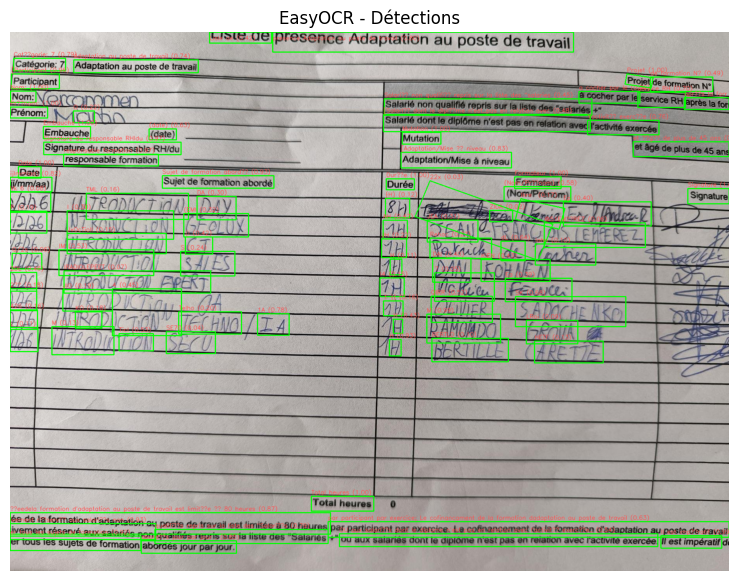

In [51]:
# OCR avec EasyOCR
# Installation si besoin: pip install easyocr torch torchvision

easyocr_text = ""
easyocr_rows = []

try:
    import easyocr

    reader = easyocr.Reader(['fr', 'en'], gpu=False)
    # Utilise l'image RGB source
    results_easy = reader.readtext(img_rgb)

    for i, (bbox, text, conf) in enumerate(results_easy, 1):
        easyocr_rows.append((i, text, float(conf), bbox))

    easyocr_text = "\n".join([r[1] for r in easyocr_rows]).strip()
    print("=== EasyOCR (texte) ===")
    print(easyocr_text if easyocr_text else "(aucun texte détecté)")

    # Visualisation des boîtes
    vis = img_rgb.copy()
    for _, txt, conf, bbox in easyocr_rows:
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(vis, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        x, y = pts[0]
        cv2.putText(vis, f"{txt} ({conf:.2f})", (x, max(20, y - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 80, 80), 1, cv2.LINE_AA)

    plt.figure(figsize=(12, 7))
    plt.imshow(vis)
    plt.title("EasyOCR - Détections")
    plt.axis('off')
    plt.show()

except Exception as e:
    print("EasyOCR non disponible ou erreur d'exécution:")
    print(e)

Kernel Python actif: c:\Users\mvm\open3d_vision\.venv\Scripts\python.exe
pytesseract déjà disponible dans le kernel.
Tesseract binaire: C:\Users\mvm\AppData\Local\Programs\Tesseract-OCR\tesseract.exe
=== Pytesseract (texte) ===
OR Saag Us nt vi OOS & PFesence Adaptation au poste de travail re Bk -
;
Nom: \/ ramen Salarié non quaiifié rapris sur ta liste des “salaries 9° Te —
Prot ACAD =F Ii ste dite resto anrasionomeeeae—e
fd pmbauahe Ses Cate) ees gh [Maton Be Sr 5 let epi de a8 os
ee ee paponeebie erates ee TA ': [AdaptatoniMice Sevens: Da
Ymmiaa) 220s eS oy, Sulet'de formation abordé AN rad ghgs | Durée | io on SEE (NonvPrénom) : ++] 7 Oe) Signature
fhe {Ihren [ES EN Fe
Yael MRAP aN” TEL hilo [La ee Dann Re ee es
IN PI OO La eae tn pe ‘Totalheues 9 >, oa Te : ne
€e de la formation d’adaptation au poste de travail est Iimitée & 80 heures par participant par exercice, Le cofinancemant de la formation d'adapiation au poste de travail
vement réservé aux salariés non qualifiés repris sur

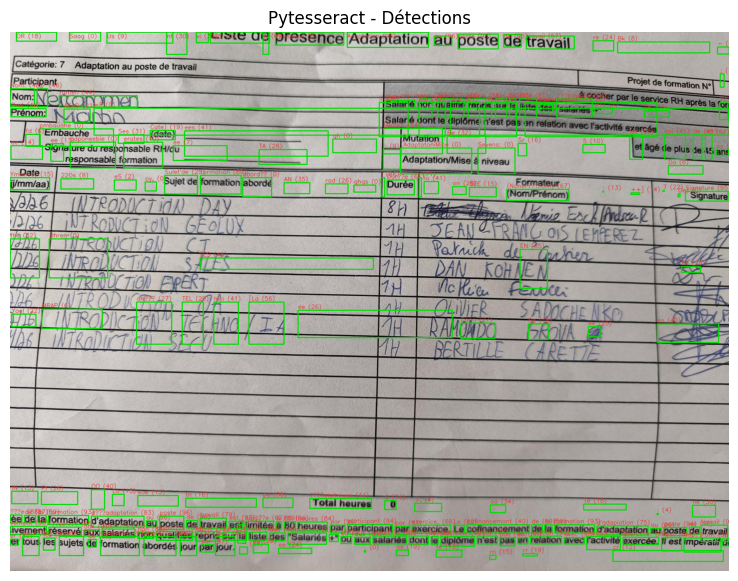

In [52]:
# OCR avec Pytesseract
# Cette cellule corrige le cas "installé dans le venv mais introuvable dans le notebook"
# en installant (si besoin) dans l'environnement Python du kernel Jupyter courant.

import os
import sys
import shutil
import importlib.util
import subprocess

pytesseract_text = ""


def _ensure_pytesseract_in_kernel():
    """Installe pytesseract dans le Python du kernel si absent."""
    spec = importlib.util.find_spec("pytesseract")
    if spec is None:
        print("pytesseract absent du kernel -> installation en cours...")
        print(f"Kernel Python: {sys.executable}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pytesseract"])
        # Re-check après installation
        spec = importlib.util.find_spec("pytesseract")
        if spec is None:
            raise ModuleNotFoundError("pytesseract toujours introuvable après installation.")
    else:
        print("pytesseract déjà disponible dans le kernel.")


try:
    print(f"Kernel Python actif: {sys.executable}")
    _ensure_pytesseract_in_kernel()

    import pytesseract
    from pytesseract import Output

    # Détection de tesseract.exe (CLI)
    def _find_tesseract_exe():
        tesseract_cli = shutil.which("tesseract")
        local_appdata = os.environ.get("LOCALAPPDATA", r"C:\Users\mvm\AppData\Local")
        candidate_paths = [
            tesseract_cli,
            os.path.join(local_appdata, "Programs", "Tesseract-OCR", "tesseract.exe"),
            os.path.join(local_appdata, "Tesseract-OCR", "tesseract.exe"),
            r"C:\Program Files\Tesseract-OCR\tesseract.exe",
            r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe",
            r"C:\Users\mvm\AppData\Local\Programs\Tesseract-OCR\tesseract.exe",
        ]
        candidate_paths = [p for p in candidate_paths if p]
        for c in candidate_paths:
            if os.path.isfile(c):
                return c
        return None

    selected_tesseract = _find_tesseract_exe()

    # Option d'installation auto (Windows + winget)
    INSTALL_TESSERACT_IF_MISSING = False
    if selected_tesseract is None and INSTALL_TESSERACT_IF_MISSING:
        print("tesseract.exe introuvable -> tentative d'installation via winget...")
        install_cmds = [
            ["winget", "install", "-e", "--id", "tesseract-ocr.tesseract"],
            ["winget", "install", "-e", "--id", "UB-Mannheim.TesseractOCR"],
        ]
        for cmd in install_cmds:
            try:
                print("Commande:", " ".join(cmd))
                subprocess.check_call(cmd)
                break
            except Exception as ie:
                print("Échec commande:", ie)

        # re-check après tentative installation
        selected_tesseract = _find_tesseract_exe()

    if selected_tesseract is not None:
        pytesseract.pytesseract.tesseract_cmd = selected_tesseract
        print(f"Tesseract binaire: {selected_tesseract}")
    else:
        raise FileNotFoundError(
            "tesseract.exe introuvable.\n"
            "Action recommandée:\n"
            "1) installer via terminal: winget install -e --id tesseract-ocr.tesseract\n"
            "2) redémarrer le kernel\n"
            "3) relancer cette cellule\n"
            "(option: mettre INSTALL_TESSERACT_IF_MISSING=True dans la cellule)"
        )

    custom_config = r"--oem 3 --psm 6"

    # Texte brut
    pytesseract_text = pytesseract.image_to_string(bin_denoised, lang="eng", config=custom_config).strip()
    print("=== Pytesseract (texte) ===")
    print(pytesseract_text if pytesseract_text else "(aucun texte détecté)")

    # Boîtes + confiance
    data = pytesseract.image_to_data(
        bin_denoised, output_type=Output.DICT, lang="eng", config=custom_config
    )

    vis_tess = img_rgb.copy()
    n = len(data["text"])
    for i in range(n):
        txt = str(data["text"][i]).strip()
        conf_str = str(data["conf"][i]).strip()
        try:
            conf = float(conf_str)
        except Exception:
            conf = -1.0

        if txt and conf >= 0:
            x = int(data["left"][i])
            y = int(data["top"][i])
            w = int(data["width"][i])
            h = int(data["height"][i])
            cv2.rectangle(vis_tess, (x, y), (x + w, y + h), (0, 220, 0), 2)
            cv2.putText(
                vis_tess,
                f"{txt} ({conf:.0f})",
                (x, max(15, y - 4)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (220, 60, 60),
                1,
                cv2.LINE_AA,
            )

    plt.figure(figsize=(12, 7))
    plt.imshow(vis_tess)
    plt.title("Pytesseract - Détections")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("Pytesseract non disponible ou erreur d'exécution:")
    print(e)
    print("Astuce: vérifier le kernel actif (menu Jupyter) et relancer cette cellule.")

In [53]:
# Résumé final des résultats OCR

def _clean_text(t):
    return "\n".join([ln.strip() for ln in str(t).splitlines() if ln.strip()])

easy_clean = _clean_text(easyocr_text) if 'easyocr_text' in globals() else ""
tess_clean = _clean_text(pytesseract_text) if 'pytesseract_text' in globals() else ""

print("=" * 80)
print("RÉSUMÉ INFÉRENCE OCR")
print("=" * 80)
print(f"Image: {IMAGE_PATH}")
print()
print("[EasyOCR]")
print(easy_clean if easy_clean else "(vide ou non exécuté)")
print()
print("[Pytesseract]")
print(tess_clean if tess_clean else "(vide ou non exécuté)")
print("=" * 80)

# Choix heuristique simple : prendre le texte le plus long non vide
candidates = [("EasyOCR", easy_clean), ("Pytesseract", tess_clean)]
candidates = [(name, txt) for name, txt in candidates if txt]
if candidates:
    best_name, best_text = max(candidates, key=lambda x: len(x[1]))
    print(f"Suggestion auto: conserver la sortie {best_name} (texte le plus riche).")
else:
    print("Aucun texte exploitable détecté. Vérifie l'installation OCR ou teste un autre prétraitement.")

RÉSUMÉ INFÉRENCE OCR
Image: C:\Users\mvm\open3d_vision\data\image_texte.jpg

[EasyOCR]
Lisle ae
presence Adaptation au poste de travail
Catégorie: 7
Adaptation au poste de travail
[Participant
de formation N?
Nom:
a cocher par le
service RH
Salarié non qualifié repris sur Ia liste des "salaries
après la forr
Prénom:
O
[Salarlé dont le dlplôme n'est_pas en relation avec
Embauche
(date)
Yactivité exercée
Mutation
Signature du responsable RHIdu
et àgé de plus de 45 ans
responsable formation
[Adaptation/Mise à niveau
Date
ijlmmlaa)
Sujet de formation abordé
Durée
Formateur
(Nom/Prénom)
Signature
Vk 6
TML
DA
{H)
ZIDA
Ep
P
I
(EMI
AH
JEA
@51EMÔREZ
JxOcTioll
(I
JH
Rehac
dL
lohn
Q/2s
IM
S
H
DAI
KIEN
2DL
IRADIOLEPEET
I4
7
Ea
2é
JIO
4
1 }}
QIRR
SK
426
KO
Telho
1A
H
M
LRoi
L
M
Ticl
SE70
H
BERTLD
HETF
Total heures
éeedela formation d'adaptation au poste de travail est limitée à 80 heures
ivement réservé aux salariés non
par participant par exercice; Le cofinancament de la formation dadaptation au p